# DSN AI Bootcamp 2026
## Multilingual Topic Classification and Headline Generation

### 1. Project Overview
### 2. Imports and Setup
### 3. Load the Dataset
### 4. Exploratory Data Analysis
### 5. Classical Baseline
### 6. Zero-Shot LLM Baseline
### 7. Few-Shot Prompting
### 8. LoRA Fine-Tuning
### 9. Model Evaluation
### 10. Error Analysis
### 11. Baseline vs Final Model
### 12. Generate Test Predictions
### 13. Create submission.csv
### 14. Conclusion
### 15. Model Card

In [1]:
!pip install -q scikit-learn

In [2]:
import sklearn
print("scikit-learn version:", sklearn.__version__)

scikit-learn version: 1.6.1


In [3]:
import sklearn
print("sklearn location:", sklearn.__file__)
print("sklearn version:", getattr(sklearn, "__version__", "No version found"))

sklearn location: /usr/local/lib/python3.12/dist-packages/sklearn/__init__.py
sklearn version: 1.6.1


In [4]:
!pip uninstall -y scikit-learn sklearn
!pip install --no-cache-dir --force-reinstall scikit-learn

Found existing installation: scikit-learn 1.6.1
Uninstalling scikit-learn-1.6.1:
  Successfully uninstalled scikit-learn-1.6.1
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.4/62.4 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 115.6 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 306.1/306.1 kB 329.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 474.0/474.0 kB 283.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 198.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 168.9 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: threadpoolctl
    Found existing installation: threadpoolctl 3.6.0
    Uninstalling threadpoolctl-3.6.0:
      Successfully uninstalled threadpoolctl-3.6.0
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: narwhals
    Fo

In [5]:
!pip uninstall -y scikit-learn sklearn

Found existing installation: scikit-learn 1.9.1
Uninstalling scikit-learn-1.9.1:
  Successfully uninstalled scikit-learn-1.9.1


In [6]:
!pip install --no-cache-dir --force-reinstall scikit-learn==1.6.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.4/62.4 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 195.0 MB/s eta 0:00:000:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 306.1/306.1 kB 353.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 183.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 242.4 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: threadpoolctl
    Found existing installation: threadpoolctl 3.7.0
    Uninstalling threadpoolctl-3.7.0:
      Successfully uninstalled threadpoolctl-3.7.0
  Attempting uninstall: numpy
    Found existing installation: numpy 2.5.3
    Uninstalling numpy-2.5.3:
      Successfully uninstalled numpy-2.5.3
  Attempting uninstall: cloudpickle
    Found existing installation: cloudpickle 3.1.2
    Uninstalling cloudpickle-3.1.2:
      Successfully uninstalled cloudpickle-3.1.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.18.

In [7]:
import sklearn

print("scikit-learn version:", sklearn.__version__)

from sklearn.metrics import f1_score, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

print("All sklearn imports successful!")

scikit-learn version: 1.6.1
All sklearn imports successful!


In [8]:
import os
import re
import json
import random
import time
import warnings

import numpy as np
import pandas as pd

from sklearn.metrics import f1_score, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings("ignore")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

print("Setup complete.")

Setup complete.


In [9]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/competitions/dsn-bootcamp-hackathon-2026-llm-agent-track/sample_submission.csv
/kaggle/input/competitions/dsn-bootcamp-hackathon-2026-llm-agent-track/train.csv
/kaggle/input/competitions/dsn-bootcamp-hackathon-2026-llm-agent-track/test.csv


In [10]:
DATA_DIR = "/kaggle/input/competitions/dsn-bootcamp-hackathon-2026-llm-agent-track"

train = pd.read_csv(f"{DATA_DIR}/train.csv")
test = pd.read_csv(f"{DATA_DIR}/test.csv")
sample_submission = pd.read_csv(f"{DATA_DIR}/sample_submission.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Sample submission shape:", sample_submission.shape)

Train shape: (6068, 7)
Test shape: (1743, 3)
Sample submission shape: (3486, 2)


In [11]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)

print("\nTrain columns:")
print(train.columns.tolist())

print("\nFirst 5 training rows:")
display(train.head())

Train shape: (6068, 7)
Test shape: (1743, 3)

Train columns:
['category', 'headline', 'text', 'url', 'id', 'split', 'lang']

First 5 training rows:


,category,headline,text,url,id,split,lang
0,health,Tí ìgbẹ́ tóò ń yà bá rí báyìí? Àìsàn jẹjẹrẹ ik...,"Ìlera ní Yorùbá pè ní oògùn ọrọ̀, àláfíà ẹni k...",https://www.bbc.com/yoruba/articles/c0w5qxr417zo,yor_0001,train,yor
1,health,Breastfeeding: Wo àwọn oúnjẹ́ tí yóò mú kí omi...,"Ọpọlọpọ ounjẹ lo wa, to le ṣe awọn iyalọmọ to ...",https://www.bbc.com/yoruba/awon-iroyin-miran-5...,yor_0002,train,yor
2,religion,Pastor Adeboye: Ìyàwó Adeboye ní ó jẹ́ okùnrin...,"Iyawo pasitọ Enoch Adeboye, Foluke Adeboye ti ...",https://www.bbc.com/yoruba/56262187,yor_0003,train,yor
3,health,"Charles Olumo Agbako ń ṣe àìsàn ńlá, ó ní ara ...","Òdú ni gbajúgbajà òṣèré tíátà nnì, Abdulsalam ...",https://www.bbc.com/yoruba/articles/cjrn5w951r4o,yor_0004,train,yor
4,religion,US Fake Marriage Pastor: Ẹ̀wọ̀n ọdún márùn-ún ...,"Olusọagutan kan ni Maryland lorilẹede Amẹrika,...",https://www.bbc.com/yoruba/afrika-59033802,yor_0005,train,yor


In [12]:
print("Categories:")
print(train["category"].value_counts())

Categories:
category
entertainment    1278
politics         1266
sports           1124
health           1030
religion          617
business          550
technology        203
Name: count, dtype: int64


In [13]:
print("Languages:")
print(train["lang"].value_counts())

Languages:
lang
hau    2219
yor    1433
ibo    1356
pcm    1060
Name: count, dtype: int64


In [14]:
print("\nTest languages:")
print(test["lang"].value_counts())


Test languages:
lang
hau    637
yor    411
ibo    390
pcm    305
Name: count, dtype: int64


In [15]:
print(train["split"].value_counts(dropna=False))

split
train    6068
Name: count, dtype: int64


In [16]:
print("Missing values in training data:")
print(train.isnull().sum())

print("\nMissing values in test data:")
print(test.isnull().sum())

Missing values in training data:
category    0
headline    0
text        0
url         0
id          0
split       0
lang        0
dtype: int64

Missing values in test data:
id      0
lang    0
text    0
dtype: int64


In [17]:
for lang in train["lang"].unique():

    print("=" * 100)
    print("LANGUAGE:", lang)

    sample = train[
        train["lang"] == lang
    ].sample(
        2,
        random_state=42
    )

    for _, row in sample.iterrows():

        print("\nCATEGORY:", row["category"])
        print("HEADLINE:", row["headline"])
        print("TEXT:", row["text"][:1000])
        print()

LANGUAGE: yor

CATEGORY: politics
HEADLINE: Attahiru Jega, APC, PDP: Ọ̀rọ̀ di gbas gbos, APC fèsì lórí ọ̀rọ̀ tí Jega sọ pé kí aráàlú má ṣé dìbo fún wọn
TEXT: Ọrọ ti di gbas gbos laarin ẹgbẹ oṣelu mejeeji to lorukọ ni Naijiria,All Progressives Congress,APC,Peoples Democratic Party PDP ati alaga tẹlẹ ri ajọ eleto idibo Attahiru Jega. Fakinfa yi ko si sẹyin ọrọ ti Ọjọgbọn Jega sọ ninu ifọrọwanilẹnuwo kan pẹlu BBC pe ki awọn ọmọ Naijiria ma se dibo fawọn ẹgbẹ yi. Latari eyi, ẹgbẹ oṣelu PDP naa ti fesi pada ti wọn si ni ki Jega ma se fi awọn we ijọba APC ti ko seso rere fawọn ọmọ Naijiria. Ṣaaju ni ẹgbẹ oṣelu APC naa ti ni ki Jega ma ṣe da awọn papọ pẹlu PDP ninu ọrọ rẹ rara ti rara nitori PDP lo ba Naijiria jẹ tawọn ṣi n gbiyanjulati ṣe atunṣe. Kola Ologbondiyan to jẹ akọwe ipolongo ẹgbẹ PDP sọ pe Jega ṣe afihan aimọkan pẹlu bi ko ṣe ri iyatọ to wa laarin ijọba awọn ati ti APC. O tẹsiwaju pe lasiko ijọba PDP idagbasoke ba ọrọ aje Naijiria ni afiwe ti APC to sọ ọpọ sinu iya ohun iṣẹ. Ologbo

In [18]:
display(sample_submission.head(20))

,id,prediction
0,yor_0001_topic,politics
1,yor_0001_headline,headline
2,yor_0002_topic,politics
3,yor_0002_headline,headline
4,yor_0003_topic,politics
5,yor_0003_headline,headline
6,yor_0004_topic,politics
7,yor_0004_headline,headline
8,yor_0005_topic,politics
9,yor_0005_headline,headline


In [19]:
print("Sample submission shape:", sample_submission.shape)
print("\nFirst IDs:")
print(sample_submission["id"].head(20).tolist())

Sample submission shape: (3486, 2)

First IDs:
['yor_0001_topic', 'yor_0001_headline', 'yor_0002_topic', 'yor_0002_headline', 'yor_0003_topic', 'yor_0003_headline', 'yor_0004_topic', 'yor_0004_headline', 'yor_0005_topic', 'yor_0005_headline', 'yor_0006_topic', 'yor_0006_headline', 'yor_0007_topic', 'yor_0007_headline', 'yor_0008_topic', 'yor_0008_headline', 'yor_0009_topic', 'yor_0009_headline', 'yor_0010_topic', 'yor_0010_headline']


In [20]:
print("Split distribution:")
print(train["split"].value_counts(dropna=False))

Split distribution:
split
train    6068
Name: count, dtype: int64


In [21]:
print("Unique split values:")
print(train["split"].unique())

Unique split values:
['train']


In [22]:
from sklearn.model_selection import train_test_split

train_data, dev_data = train_test_split(
    train,
    test_size=0.15,
    random_state=42,
    stratify=train["category"]
)

print("Training set:", train_data.shape)
print("Validation set:", dev_data.shape)

Training set: (5157, 7)
Validation set: (911, 7)


In [23]:
print("Training categories:")
print(train_data["category"].value_counts())

print("\nValidation categories:")
print(dev_data["category"].value_counts())

Training categories:
category
entertainment    1086
politics         1076
sports            955
health            875
religion          524
business          468
technology        173
Name: count, dtype: int64

Validation categories:
category
entertainment    192
politics         190
sports           169
health           155
religion          93
business          82
technology        30
Name: count, dtype: int64


In [24]:
pd.crosstab(
    dev_data["lang"],
    dev_data["category"]
)

category,business,entertainment,health,politics,religion,sports,technology
lang,,,,,,,
hau,43,63,50,51,55,66,30
ibo,29,48,42,53,2,24,0
pcm,10,38,23,36,0,48,0
yor,0,43,40,50,36,31,0


In [25]:
X_train = train_data["text"].fillna("")
y_train = train_data["category"]

X_dev = dev_data["text"].fillna("")
y_dev = dev_data["category"]

In [26]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_features=100000,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_dev_tfidf = tfidf.transform(X_dev)

print("Training matrix:", X_train_tfidf.shape)
print("Validation matrix:", X_dev_tfidf.shape)

Training matrix: (5157, 100000)
Validation matrix: (911, 100000)


In [27]:
classifier = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

classifier.fit(
    X_train_tfidf,
    y_train
)

print("Model trained successfully!")

Model trained successfully!


In [28]:
classical_predictions = classifier.predict(X_dev_tfidf)

print(classical_predictions[:20])

['politics' 'politics' 'politics' 'politics' 'health' 'politics'
 'business' 'health' 'politics' 'politics' 'religion' 'sports' 'politics'
 'religion' 'politics' 'health' 'health' 'health' 'health' 'entertainment']


In [29]:
classical_macro_f1 = f1_score(
    y_dev,
    classical_predictions,
    average="macro"
)

print(
    f"Classical Baseline Macro-F1: "
    f"{classical_macro_f1:.4f}"
)

Classical Baseline Macro-F1: 0.8360


In [30]:
print(
    classification_report(
        y_dev,
        classical_predictions
    )
)

               precision    recall  f1-score   support

     business       0.66      0.82      0.73        82
entertainment       0.86      0.82      0.84       192
       health       0.96      0.86      0.91       155
     politics       0.92      0.85      0.88       190
     religion       0.82      0.83      0.82        93
       sports       0.97      0.95      0.96       169
   technology       0.56      0.93      0.70        30

     accuracy                           0.86       911
    macro avg       0.82      0.87      0.84       911
 weighted avg       0.88      0.86      0.87       911



In [31]:
dev_results = dev_data.copy()

dev_results["prediction"] = classical_predictions

In [32]:
language_scores = {}

for language in sorted(dev_results["lang"].unique()):

    subset = dev_results[
        dev_results["lang"] == language
    ]

    score = f1_score(
        subset["category"],
        subset["prediction"],
        average="macro"
    )

    language_scores[language] = score

language_scores

{'hau': 0.8554645638059981,
 'ibo': 0.6979417417060437,
 'pcm': 0.830026612332335,
 'yor': 0.8778302737741128}

In [33]:
for language, score in language_scores.items():
    print(f"{language}: {score:.4f}")

hau: 0.8555
ibo: 0.6979
pcm: 0.8300
yor: 0.8778


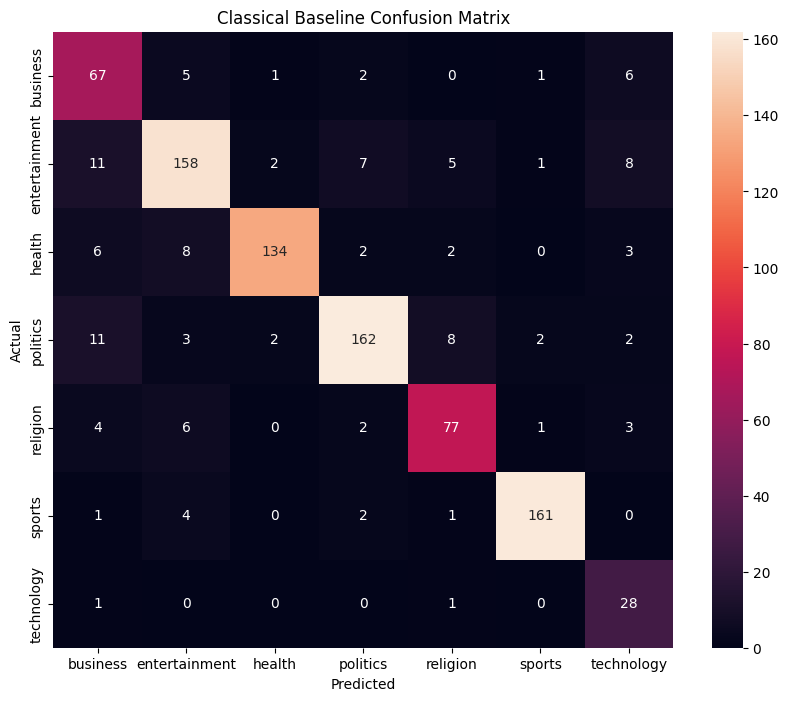

In [34]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(
    y_dev,
    classical_predictions,
    labels=sorted(train["category"].unique())
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=sorted(train["category"].unique()),
    yticklabels=sorted(train["category"].unique())
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Classical Baseline Confusion Matrix")
plt.show()

In [35]:
baseline_results = pd.DataFrame({
    "Model": ["TF-IDF + Logistic Regression"],
    "Macro-F1": [classical_macro_f1]
})

baseline_results

,Model,Macro-F1
0,TF-IDF + Logistic Regression,0.83597


In [36]:
def extractive_headline(text, max_words=20):
    text = str(text).strip()

    # Clean excessive whitespace
    text = re.sub(r"\s+", " ", text)

    # Split into sentences
    sentences = re.split(r"(?<=[.!?])\s+", text)

    # Remove empty sentences
    sentences = [s.strip() for s in sentences if s.strip()]

    if not sentences:
        return text[:150]

    headline = sentences[0]

    # Limit length
    words = headline.split()

    if len(words) > max_words:
        headline = " ".join(words[:max_words])

    return headline

In [37]:
dev_results["classical_headline"] = (
    dev_results["text"]
    .apply(extractive_headline)
)

In [38]:
display(
    dev_results[
        ["lang", "category", "headline", "classical_headline"]
    ].head(10)
)

,lang,category,headline,classical_headline
4068,hau,politics,Mahadi Aliyu: 'Yan majalisa na son tsige ni da...,Latsa hoton dake sama domin kallon hirar: Mata...
2242,pcm,politics,"Imo state news: Hope Uzodinma, police launch ‘...",South east Nigeria don calm compared to wetin ...
5577,hau,politics,Aisha Buhari: Katin gayyatar 'yan takara da ma...,"Sunan Aisha Buhari, matar Shugaban Najeriya Mu..."
1623,pcm,politics,Election Tribunal: Atiku wan carri 400 witness...,Presidential candidate for Nigeria 2019 electi...
1772,pcm,health,Wetin di new Covid-19 guildelines for Nigeria ...,Nigeria goment say wearing of Facemasks inside...
881,yor,politics,"Ẹ bá wa sọ̀rọ̀, ààyè ṣì wà fún ìjíròrò - Àwọn ...",Awọn gomina marun un lati inu ẹgbẹ oṣelu PDP t...
4301,hau,business,Amfani biyar game da samun man fetur a Arewaci...,A﻿ ranar Talata shugaban Najeriya Muhammadu Bu...
120,yor,entertainment,Ada Jesus death: Ṣé òtítọ́ ni pé ikú apanilẹ́ẹ...,Harrison Gwamnishu to jẹ olutọju adẹrinpoṣonu ...
3746,ibo,politics,Kingsley Moghalu: Ndị kwe ndị ekweghi so na-eb...,Kingsley Boseh Ayodele Moghalu bụ nwafọ Igbo b...
1110,yor,politics,"""Ẹ jẹ́ ká pa ẹgbẹ́ ọ̀tún tì ká pa tí òsì tì ká...",Ọmọwe Akinade Ogunbiyi to jẹ oludije fun ipo g...


In [39]:
!pip install -q rouge-score

In [40]:
from rouge_score import rouge_scorer

rouge = rouge_scorer.RougeScorer(
    ["rougeL"],
    use_stemmer=False
)

In [41]:
rouge_scores = []

for _, row in dev_results.iterrows():

    reference = str(row["headline"])
    prediction = str(row["classical_headline"])

    score = rouge.score(
        reference,
        prediction
    )

    rouge_scores.append(
        score["rougeL"].fmeasure
    )

classical_rouge_l = np.mean(rouge_scores)

print(
    f"Classical Headline ROUGE-L F1: "
    f"{classical_rouge_l:.4f}"
)

Classical Headline ROUGE-L F1: 0.2383


In [42]:
dev_results["rougeL"] = rouge_scores

In [43]:
for language in sorted(dev_results["lang"].unique()):

    score = dev_results.loc[
        dev_results["lang"] == language,
        "rougeL"
    ].mean()

    print(
        f"{language}: {score:.4f}"
    )

hau: 0.2650
ibo: 0.2157
pcm: 0.2793
yor: 0.1810


In [44]:
worst_headlines = dev_results.sort_values(
    "rougeL"
).head(10)

display(
    worst_headlines[
        [
            "lang",
            "category",
            "headline",
            "classical_headline",
            "rougeL"
        ]
    ]
)

,lang,category,headline,classical_headline,rougeL
2242,pcm,politics,"Imo state news: Hope Uzodinma, police launch ‘...",South east Nigeria don calm compared to wetin ...,0.0
3798,ibo,entertainment,The First Temptation of Christ: Netflix o mere...,#BoycottNetflix na-ewu na soshal midịa dịka nd...,0.0
761,yor,health,Covid toe: Ṣé o mọ̀ pé o leè kó Covid pẹ̀lú ọm...,Awọn onimọ Sayẹnsi gbagbọ pe awọn lee ṣalaye i...,0.0
974,yor,entertainment,"Ohun tó pa Yemi Adegunju, òṣèré tíátà tó jáde ...","Igi ti da, Erin wo, Ajanaku ti sun bii oke, ọf...",0.0
4046,hau,entertainment,Girke-Girken Ramadan: Yadda ake hada cucumber ...,Danna hoton da ke sama domin kallon bidiyon: W...,0.0
5511,hau,politics,Adamu Garba: Idan na sayi fom a kan N100m za a...,Danna hoton da ke sama domin kallon bidiyon: M...,0.0
1707,pcm,entertainment,"Valentine's day messages: 'I be Igbo, she be Y...",Dis na di love tori of Oluyemisi Dada and Godw...,0.0
609,yor,sports,Diego Maradona: Ohun mẹ́wàá pàtàkì nípa Marado...,"Erin wo, ajanaku sun bi oke!",0.0
3253,ibo,health,Overcoming depression: ‘Ịzụ ụmụanụmanụ dọpụtar...,Iyke Elueze nwa afọ Igbo ndụ na-atọ ka nnu.,0.0
3603,ibo,health,Coronavirus Lockdown: Etu ị ga-esi kwado dika ...,Ndị Igbo na-asị na nkwụcha abụghị ụjọ.,0.0


In [45]:
baseline_results = pd.DataFrame({
    "Model": [
        "TF-IDF + Logistic Regression",
        "Lead-1 Extractive"
    ],
    "Macro-F1": [
        classical_macro_f1,
        np.nan
    ],
    "ROUGE-L": [
        np.nan,
        classical_rouge_l
    ]
})

baseline_results

,Model,Macro-F1,ROUGE-L
0,TF-IDF + Logistic Regression,0.83597,NaN
1,Lead-1 Extractive,NaN,0.238261


In [46]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [47]:
import transformers

print("Transformers version:", transformers.__version__)

Transformers version: 5.0.0


In [48]:
import torch

print(
    "Available GPU memory:",
    torch.cuda.get_device_properties(0).total_memory / 1e9
    if torch.cuda.is_available()
    else "No GPU"
)

Available GPU memory: 15.636037632


In [49]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto"
)

print("Model loaded successfully!")
print("Device:", next(model.parameters()).device)

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Model loaded successfully!
Device: cuda:0


In [50]:
prompt = """You are a news topic classifier.

Classify the following news article into exactly one of these categories:
business, health, politics, religion, sports, entertainment, technology.

Article:
The government announced a new programme to support small businesses with access to funding and training.

Return only the category name.
"""

messages = [
    {"role": "user", "content": prompt}
]

text = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)

inputs = tokenizer(text, return_tensors="pt").to(model.device)

with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=10,
        do_sample=False
    )

response = tokenizer.decode(
    outputs[0][inputs["input_ids"].shape[1]:],
    skip_special_tokens=True
)

print("Model response:", response)

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Model response: business


In [51]:
LABELS = [
    "business",
    "health",
    "politics",
    "religion",
    "sports",
    "entertainment",
    "technology"
]

def extract_label(response):
    """
    Extract one of the valid topic labels from the model response.
    """
    response = response.lower().strip()

    for label in LABELS:
        if label in response:
            return label

    return "unknown"


def zero_shot_topic(text):
    prompt = f"""You are a multilingual news topic classifier.

Classify the news article into exactly ONE of these categories:

business
health
politics
religion
sports
entertainment
technology

The article may be written in Hausa, Igbo, Yoruba, or Nigerian Pidgin.

Return ONLY the category name.

News article:
{text}
"""

    messages = [
        {"role": "user", "content": prompt}
    ]

    formatted_prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(
        formatted_prompt,
        return_tensors="pt",
        truncation=True,
        max_length=1024
    ).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=8,
            do_sample=False
        )

    generated_tokens = outputs[0][inputs["input_ids"].shape[1]:]

    response = tokenizer.decode(
        generated_tokens,
        skip_special_tokens=True
    )

    return extract_label(response)

In [52]:
for i in range(5):
    row = dev_data.iloc[i]

    prediction = zero_shot_topic(row["text"])

    print("=" * 70)
    print("Language:", row["lang"])
    print("Actual:", row["category"])
    print("Predicted:", prediction)
    print("Headline:", row["headline"])

Language: hau
Actual: politics
Predicted: entertainment
Headline: Mahadi Aliyu: 'Yan majalisa na son tsige ni daga mataimakin gwamnan Zamfara ne saboda na ƙi komawa APC
Language: pcm
Actual: politics
Predicted: technology
Headline: Imo state news: Hope Uzodinma, police launch ‘operation search and flush’
Language: hau
Actual: politics
Predicted: business
Headline: Aisha Buhari: Katin gayyatar 'yan takara da matar shugaban ƙasar ta aika na tayar da ƙura a Najeriya
Language: pcm
Actual: politics
Predicted: unknown
Headline: Election Tribunal: Atiku wan carri 400 witness come court to testify against Buhari re-election
Language: pcm
Actual: health
Predicted: technology
Headline: Wetin di new Covid-19 guildelines for Nigeria mean for pipo wey dey travel by air?


In [53]:
zero_shot_predictions = []

start_time = time.time()

for i, text in enumerate(dev_data["text"].fillna("")):
    prediction = zero_shot_topic(text)
    zero_shot_predictions.append(prediction)

    if (i + 1) % 25 == 0:
        elapsed = time.time() - start_time
        print(f"Processed {i + 1}/{len(dev_data)} articles | "
              f"Time: {elapsed/60:.1f} min")

print("Finished!")

Processed 25/911 articles | Time: 0.1 min
Processed 50/911 articles | Time: 0.2 min
Processed 75/911 articles | Time: 0.3 min
Processed 100/911 articles | Time: 0.4 min
Processed 125/911 articles | Time: 0.5 min
Processed 150/911 articles | Time: 0.6 min
Processed 175/911 articles | Time: 0.7 min
Processed 200/911 articles | Time: 0.8 min
Processed 225/911 articles | Time: 0.9 min
Processed 250/911 articles | Time: 1.0 min
Processed 275/911 articles | Time: 1.1 min
Processed 300/911 articles | Time: 1.2 min
Processed 325/911 articles | Time: 1.3 min
Processed 350/911 articles | Time: 1.4 min
Processed 375/911 articles | Time: 1.4 min
Processed 400/911 articles | Time: 1.5 min
Processed 425/911 articles | Time: 1.7 min
Processed 450/911 articles | Time: 1.8 min
Processed 475/911 articles | Time: 1.9 min
Processed 500/911 articles | Time: 2.0 min
Processed 525/911 articles | Time: 2.1 min
Processed 550/911 articles | Time: 2.2 min
Processed 575/911 articles | Time: 2.3 min
Processed 600/

In [54]:
zero_shot_f1 = f1_score(
    dev_data["category"],
    zero_shot_predictions,
    average="macro"
)

print(f"Zero-shot Macro-F1: {zero_shot_f1:.6f}")

Zero-shot Macro-F1: 0.280338


In [55]:
dev_results["zero_shot_prediction"] = zero_shot_predictions

In [56]:
print("Zero-shot Macro-F1 by language")
print("=" * 50)

for language in sorted(dev_data["lang"].unique()):
    mask = dev_data["lang"] == language

    score = f1_score(
        dev_data.loc[mask, "category"],
        np.array(zero_shot_predictions)[mask],
        average="macro"
    )

    print(f"{language}: {score:.6f}")

Zero-shot Macro-F1 by language
hau: 0.262681
ibo: 0.198908
pcm: 0.350228
yor: 0.173415


In [57]:
baseline_results = pd.DataFrame([
    {
        "Approach": "TF-IDF + Logistic Regression",
        "Task": "Topic Classification",
        "Macro-F1": classical_macro_f1,
        "ROUGE-L": np.nan
    },
    {
        "Approach": "Lead-1 Extractive",
        "Task": "Headline Generation",
        "Macro-F1": np.nan,
        "ROUGE-L": 0.238261
    },
    {
        "Approach": "Qwen2.5-0.5B Zero-Shot",
        "Task": "Topic Classification",
        "Macro-F1": zero_shot_f1,
        "ROUGE-L": np.nan
    }
])

baseline_results

,Approach,Task,Macro-F1,ROUGE-L
0,TF-IDF + Logistic Regression,Topic Classification,0.835970,NaN
1,Lead-1 Extractive,Headline Generation,NaN,0.238261
2,Qwen2.5-0.5B Zero-Shot,Topic Classification,0.280338,NaN


In [58]:
print(f"Zero-shot Macro-F1: {zero_shot_f1:.6f}")

Zero-shot Macro-F1: 0.280338


In [59]:
# One example for each category and language
few_shot_examples = {}

for language in sorted(train_data["lang"].unique()):
    language_data = train_data[train_data["lang"] == language]

    examples = []

    for category in LABELS:
        candidates = language_data[
            language_data["category"] == category
        ]

        if len(candidates) > 0:
            row = candidates.iloc[0]

            # Keeping examples short to control prompt length
            example_text = str(row["text"]).strip()
            example_text = re.sub(r"\s+", " ", example_text)

            if len(example_text) > 700:
                example_text = example_text[:700] + "..."

            examples.append({
                "text": example_text,
                "category": category
            })

    few_shot_examples[language] = examples

for language, examples in few_shot_examples.items():
    print(language, "->", len(examples), "examples")

hau -> 7 examples
ibo -> 6 examples
pcm -> 5 examples
yor -> 5 examples


In [60]:
def few_shot_topic(text, language):
    examples = few_shot_examples.get(language, [])

    example_block = ""

    for i, example in enumerate(examples, 1):
        example_block += f"""
Example {i}
Article:
{example["text"]}

Topic:
{example["category"]}
"""

    prompt = f"""You are a multilingual news topic classifier.

The article is written in {language}.

Choose exactly ONE topic from:

business
health
politics
religion
sports
entertainment
technology

Study the examples and classify the new article.

{example_block}

Now classify this article:

{text}

Return ONLY the topic name.
"""

    messages = [
        {"role": "user", "content": prompt}
    ]

    formatted_prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(
        formatted_prompt,
        return_tensors="pt",
        truncation=True,
        max_length=2048
    ).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=8,
            do_sample=False
        )

    generated_tokens = outputs[0][inputs["input_ids"].shape[1]:]

    response = tokenizer.decode(
        generated_tokens,
        skip_special_tokens=True
    )

    return extract_label(response)

In [61]:
for i in range(5):
    row = dev_data.iloc[i]

    prediction = few_shot_topic(
        row["text"],
        row["lang"]
    )

    print("=" * 70)
    print("Language:", row["lang"])
    print("Actual:", row["category"])
    print("Predicted:", prediction)

Language: hau
Actual: politics
Predicted: business
Language: pcm
Actual: politics
Predicted: politics
Language: hau
Actual: politics
Predicted: unknown
Language: pcm
Actual: politics
Predicted: politics
Language: pcm
Actual: health
Predicted: politics


In [62]:
few_shot_predictions = []

start_time = time.time()

for i, (_, row) in enumerate(dev_data.iterrows()):
    prediction = few_shot_topic(
        row["text"],
        row["lang"]
    )

    few_shot_predictions.append(prediction)

    if (i + 1) % 25 == 0:
        elapsed = time.time() - start_time
        print(
            f"Processed {i+1}/{len(dev_data)} | "
            f"Time: {elapsed/60:.1f} min"
        )

print("Few-shot classification complete.")

Processed 25/911 | Time: 0.3 min
Processed 50/911 | Time: 0.5 min
Processed 75/911 | Time: 0.8 min
Processed 100/911 | Time: 1.1 min
Processed 125/911 | Time: 1.4 min
Processed 150/911 | Time: 1.7 min
Processed 175/911 | Time: 1.9 min
Processed 200/911 | Time: 2.2 min
Processed 225/911 | Time: 2.5 min
Processed 250/911 | Time: 2.8 min
Processed 275/911 | Time: 3.1 min
Processed 300/911 | Time: 3.4 min
Processed 325/911 | Time: 3.6 min
Processed 350/911 | Time: 3.9 min
Processed 375/911 | Time: 4.2 min
Processed 400/911 | Time: 4.5 min
Processed 425/911 | Time: 4.8 min
Processed 450/911 | Time: 5.1 min
Processed 475/911 | Time: 5.4 min
Processed 500/911 | Time: 5.7 min
Processed 525/911 | Time: 6.0 min
Processed 550/911 | Time: 6.3 min
Processed 575/911 | Time: 6.5 min
Processed 600/911 | Time: 6.8 min
Processed 625/911 | Time: 7.1 min
Processed 650/911 | Time: 7.3 min
Processed 675/911 | Time: 7.6 min
Processed 700/911 | Time: 7.9 min
Processed 725/911 | Time: 8.2 min
Processed 750/911

In [63]:
few_shot_f1 = f1_score(
    dev_data["category"],
    few_shot_predictions,
    average="macro"
)

print(f"Few-shot Macro-F1: {few_shot_f1:.6f}")

Few-shot Macro-F1: 0.116628


In [64]:
print("Few-shot Macro-F1 by language")
print("=" * 50)

few_shot_array = np.array(few_shot_predictions)

for language in sorted(dev_data["lang"].unique()):
    mask = dev_data["lang"].to_numpy() == language

    score = f1_score(
        dev_data.loc[mask, "category"],
        few_shot_array[mask],
        average="macro"
    )

    print(f"{language}: {score:.6f}")

Few-shot Macro-F1 by language
hau: 0.061368
ibo: 0.070856
pcm: 0.319212
yor: 0.025974


In [65]:
def generate_headline(text):
    prompt = f"""You are a professional multilingual news editor.

Write a concise and informative news headline for the article below.

Important instructions:
- Write the headline in the same language as the article.
- Preserve the main event or information.
- Do not invent facts.
- Do not add explanations.
- Return ONLY the headline.
- Keep it concise.

Article:
{text}
"""

    messages = [
        {"role": "user", "content": prompt}
    ]

    formatted_prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(
        formatted_prompt,
        return_tensors="pt",
        truncation=True,
        max_length=2048
    ).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=32,
            do_sample=False
        )

    generated_tokens = outputs[0][inputs["input_ids"].shape[1]:]

    headline = tokenizer.decode(
        generated_tokens,
        skip_special_tokens=True
    )

    headline = re.sub(r"\s+", " ", headline).strip()

    return headline

In [66]:
for i in range(5):
    row = dev_data.iloc[i]

    generated = generate_headline(row["text"])

    print("=" * 70)
    print("Language:", row["lang"])
    print("Reference:", row["headline"])
    print("Generated:", generated)

Language: hau
Reference: Mahadi Aliyu: 'Yan majalisa na son tsige ni daga mataimakin gwamnan Zamfara ne saboda na ƙi komawa APC
Generated: Mataimakin gwamnan Zamfara, Mahdi Aliyu Gusau, ake shirin tsigewa ya ci masu bit
Language: pcm
Reference: Imo state news: Hope Uzodinma, police launch ‘operation search and flush’
Generated: President Buhari warns against violence in South East Nigeria: 'Dot in a Circle' doesn't exist
Language: hau
Reference: Aisha Buhari: Katin gayyatar 'yan takara da matar shugaban ƙasar ta aika na tayar da ƙura a Najeriya
Generated: "Shugaban Najeriya Matar Aisha Buhari: 500,000+ Unpaid Workers Unite to Demand Fair
Language: pcm
Reference: Election Tribunal: Atiku wan carri 400 witness come court to testify against Buhari re-election
Generated: "Presidential Candidate's Petition Tribunal: 400 Witnesses Present, Imending Electoral Act Required"
Language: pcm
Reference: Wetin di new Covid-19 guildelines for Nigeria mean for pipo wey dey travel by air?
Generated: Ni

In [67]:
llm_headlines = []

start_time = time.time()

for i, text in enumerate(dev_data["text"].fillna("")):
    headline = generate_headline(text)
    llm_headlines.append(headline)

    if (i + 1) % 25 == 0:
        elapsed = time.time() - start_time
        print(
            f"Processed {i+1}/{len(dev_data)} | "
            f"Time: {elapsed/60:.1f} min"
        )

print("Headline generation complete.")

Processed 25/911 | Time: 0.6 min
Processed 50/911 | Time: 1.2 min
Processed 75/911 | Time: 1.6 min
Processed 100/911 | Time: 2.2 min
Processed 125/911 | Time: 2.7 min
Processed 150/911 | Time: 3.2 min
Processed 175/911 | Time: 3.7 min
Processed 200/911 | Time: 4.2 min
Processed 225/911 | Time: 4.8 min
Processed 250/911 | Time: 5.3 min
Processed 275/911 | Time: 5.9 min
Processed 300/911 | Time: 6.4 min
Processed 325/911 | Time: 6.9 min
Processed 350/911 | Time: 7.4 min
Processed 375/911 | Time: 8.0 min
Processed 400/911 | Time: 8.5 min
Processed 425/911 | Time: 9.0 min
Processed 450/911 | Time: 9.5 min
Processed 475/911 | Time: 10.0 min
Processed 500/911 | Time: 10.6 min
Processed 525/911 | Time: 11.1 min
Processed 550/911 | Time: 11.6 min
Processed 575/911 | Time: 12.1 min
Processed 600/911 | Time: 12.7 min
Processed 625/911 | Time: 13.2 min
Processed 650/911 | Time: 13.7 min
Processed 675/911 | Time: 14.2 min
Processed 700/911 | Time: 14.7 min
Processed 725/911 | Time: 15.2 min
Proces

In [68]:
rouge_scores = []

for reference, prediction in zip(
    dev_data["headline"].fillna(""),
    llm_headlines
):
    score = rouge.score(
        str(reference),
        str(prediction)
    )

    rouge_scores.append(score["rougeL"].fmeasure)

llm_rouge_l = np.mean(rouge_scores)

print(f"Qwen Zero-Shot Headline ROUGE-L: {llm_rouge_l:.6f}")

Qwen Zero-Shot Headline ROUGE-L: 0.160982


In [69]:
!pip install -q bert-score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 1.8 MB/s eta 0:00:00


In [70]:
from bert_score import score as bert_score

In [71]:
P, R, F1 = bert_score(
    llm_headlines,
    dev_data["headline"].fillna("").tolist(),
    model_type="bert-base-multilingual-cased",
    device="cuda",
    batch_size=16,
    verbose=True
)

llm_bertscore = F1.mean().item()

print(f"BERTScore F1: {llm_bertscore:.6f}")

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

...

calculating scores...
computing bert embedding.


  0%|          | 0/114 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/57 [00:00<?, ?it/s]

done in 4.45 seconds, 204.59 sentences/sec
BERTScore F1: 0.657305


In [72]:
llm_genscore = (
    0.5 * llm_rouge_l +
    0.5 * llm_bertscore
)

print(f"Qwen GenScore: {llm_genscore:.6f}")

Qwen GenScore: 0.409144


In [73]:
lead_bertscore = bert_score(
    dev_results["classical_headline"].tolist(),
    dev_data["headline"].fillna("").tolist(),
    model_type="bert-base-multilingual-cased",
    device="cuda",
    batch_size=16,
    verbose=True
)[2].mean().item()

lead_genscore = (
    0.5 * 0.238261 +
    0.5 * lead_bertscore
)

print(f"Lead-1 GenScore: {lead_genscore:.6f}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


calculating scores...
computing bert embedding.


  0%|          | 0/114 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/57 [00:00<?, ?it/s]

done in 4.85 seconds, 187.68 sentences/sec
Lead-1 GenScore: 0.477727


In [74]:
results = pd.DataFrame([
    {
        "Approach": "TF-IDF + Logistic Regression",
        "Task": "Topic Classification",
        "Macro-F1": classical_macro_f1,
        "ROUGE-L": np.nan,
        "BERTScore": np.nan,
        "GenScore": np.nan
    },
    {
        "Approach": "Qwen2.5-0.5B Zero-Shot",
        "Task": "Topic Classification",
        "Macro-F1": zero_shot_f1,
        "ROUGE-L": np.nan,
        "BERTScore": np.nan,
        "GenScore": np.nan
    },
    {
        "Approach": "Qwen2.5-0.5B Few-Shot",
        "Task": "Topic Classification",
        "Macro-F1": few_shot_f1,
        "ROUGE-L": np.nan,
        "BERTScore": np.nan,
        "GenScore": np.nan
    },
    {
        "Approach": "Lead-1 Extractive",
        "Task": "Headline Generation",
        "Macro-F1": np.nan,
        "ROUGE-L": 0.238261,
        "BERTScore": lead_bertscore,
        "GenScore": lead_genscore
    },
    {
        "Approach": "Qwen2.5-0.5B Zero-Shot",
        "Task": "Headline Generation",
        "Macro-F1": np.nan,
        "ROUGE-L": llm_rouge_l,
        "BERTScore": llm_bertscore,
        "GenScore": llm_genscore
    }
])

results

,Approach,Task,Macro-F1,ROUGE-L,BERTScore,GenScore
0,TF-IDF + Logistic Regression,Topic Classification,0.835970,NaN,NaN,NaN
1,Qwen2.5-0.5B Zero-Shot,Topic Classification,0.280338,NaN,NaN,NaN
2,Qwen2.5-0.5B Few-Shot,Topic Classification,0.116628,NaN,NaN,NaN
3,Lead-1 Extractive,Headline Generation,NaN,0.238261,0.717193,0.477727
4,Qwen2.5-0.5B Zero-Shot,Headline Generation,NaN,0.160982,0.657305,0.409144


In [75]:
!pip install -q peft accelerate

In [76]:
from peft import LoraConfig, get_peft_model, TaskType

print("PEFT imported successfully")

PEFT imported successfully


In [77]:
lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj"
    ],
    bias="none"
)

In [78]:
!pip uninstall -y torchao

Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0


In [79]:
import torch
import transformers

print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("CUDA:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.10.0+cu128
Transformers: 5.0.0
CUDA: True
GPU: Tesla T4


In [80]:
import peft

print("PEFT:", peft.__version__)

PEFT: 0.19.1


In [81]:
from transformers import AutoTokenizer, AutoModelForCausalLM

MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto"
)

print("Model loaded successfully!")
print("Device:", next(model.parameters()).device)

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Model loaded successfully!
Device: cuda:0


In [82]:
model_lora = get_peft_model(
    model,
    lora_config
)

model_lora.print_trainable_parameters()

trainable params: 1,081,344 || all params: 495,114,112 || trainable%: 0.2184


In [83]:
def create_topic_prompt(row):
    return f"""You are a multilingual news topic classifier.

The article is written in {row['lang']}.

Classify the article into exactly one of these categories:
business, health, politics, religion, sports, entertainment, technology.

Article:
{row['text']}

Topic:
{row['category']}"""

In [84]:
print(create_topic_prompt(train_data.iloc[0]))

You are a multilingual news topic classifier.

The article is written in ibo.

Classify the article into exactly one of these categories:
business, health, politics, religion, sports, entertainment, technology.

Article:
Gọvanọ Nyesom Wike nke Rivas Steeti emeriela ọzọ na ntuliaka ọkwa gọvanọ nke Rivas Steeti. Ụlọọrụ Inec na Rivas Steeti kpọpụtara mmeri Wike n'ehihie Wednezde n'ọnụ vootu dị 886,264 dịka Ọkamụta Teddy Adias bụ onye 'Returning Officer' na ntuliaka ahụ. Onye AAC bụ Biokpomabo Awara nwetere vootu dị 173,859 iji na-esote Wike n'azụ na ntuliaka emere n'abalị itoolu nke ọnwa Maachị Mpụtara ntụliaka a bụ vootu si n'okpuruọchịchị iri abụọ na otu n'ime okpuruọchịchị iri abụọ na atọ nke mejupụtara Rivas Steeti. Okpuruọchịchị Abua Odua na Gokana enweghi ihe mpụtara ọbụla n'ihi ọgbaghara dapụtara mgbe a na-eme ntuliaka nakwa mgbe a na-agụkọ mpụtara ntuliaka ebe ndị ahụ. Nke a si na mkpesa Gbaranor Godwill Christian mere mkpesa nke a dịka a na-achọ ịgụkọ mpụtara ntulaiaka. Ụlọọrụ In

In [85]:
from datasets import Dataset

train_topic_df = train_data[["text", "category", "lang"]].copy()
dev_topic_df = dev_data[["text", "category", "lang"]].copy()

train_topic_df["prompt"] = train_topic_df.apply(
    create_topic_prompt,
    axis=1
)

dev_topic_df["prompt"] = dev_topic_df.apply(
    create_topic_prompt,
    axis=1
)

train_dataset = Dataset.from_pandas(
    train_topic_df[["prompt"]],
    preserve_index=False
)

dev_dataset = Dataset.from_pandas(
    dev_topic_df[["prompt"]],
    preserve_index=False
)

print(train_dataset)
print(dev_dataset)

Dataset({
    features: ['prompt'],
    num_rows: 5157
})
Dataset({
    features: ['prompt'],
    num_rows: 911
})


In [96]:
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

print("Pad token:", tokenizer.pad_token)
print("Pad token ID:", tokenizer.pad_token_id)

Pad token: <|im_end|>
Pad token ID: 151645


In [98]:
if 'tokenized_train' in globals():
    del tokenized_train

if 'tokenized_dev' in globals():
    del tokenized_dev

In [88]:
def tokenize_function(examples):
    return tokenizer(
        examples["prompt"],
        truncation=True,
        padding="max_length",
        max_length=512
    )

tokenized_train = train_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["prompt"]
)

tokenized_dev = dev_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["prompt"]
)

print(tokenized_train.column_names)
print(type(tokenized_train[0]["input_ids"]))
print(len(tokenized_train[0]["input_ids"]))

Map:   0%|          | 0/5157 [00:00<?, ? examples/s]

Map:   0%|          | 0/911 [00:00<?, ? examples/s]

['input_ids', 'attention_mask']
<class 'list'>
512


In [89]:
from transformers import DataCollatorForLanguageModeling

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False
)

In [90]:
test_batch = data_collator([
    tokenized_train[0],
    tokenized_train[1]
])

for key, value in test_batch.items():
    print(key, type(value), value.shape)

input_ids <class 'torch.Tensor'> torch.Size([2, 512])
attention_mask <class 'torch.Tensor'> torch.Size([2, 512])
labels <class 'torch.Tensor'> torch.Size([2, 512])


In [91]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="./qwen_topic_lora",
    num_train_epochs=2,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=8,
    learning_rate=2e-4,
    fp16=True,
    logging_steps=25,
    save_strategy="epoch",
    eval_strategy="epoch",
    report_to="none",
    remove_unused_columns=False
)

trainer = Trainer(
    model=model_lora,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_dev,
    data_collator=data_collator
)

print("Trainer ready.")

Trainer ready.


In [92]:
test_batch = data_collator([
    tokenized_train[i]
    for i in range(2)
])

for key, value in test_batch.items():
    print(key, value.shape)

input_ids torch.Size([2, 512])
attention_mask torch.Size([2, 512])
labels torch.Size([2, 512])


In [93]:
from transformers import Trainer

trainer = Trainer(
    model=model_lora,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_dev,
    data_collator=data_collator
)

print("Trainer ready.")

Trainer ready.


In [99]:
train_result = trainer.train()

Epoch,Training Loss,Validation Loss
1,3.250145,3.222582
2,3.180995,3.165479


In [100]:
trainer.save_model("./qwen_topic_lora")
tokenizer.save_pretrained("./qwen_topic_lora")

print("LoRA model saved successfully.")

LoRA model saved successfully.


In [101]:
from peft import PeftModel
from transformers import AutoModelForCausalLM, AutoTokenizer

base_model = AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen2.5-0.5B-Instruct",  # use your actual base model name
    torch_dtype="auto",
    device_map="auto"
)

model_lora = PeftModel.from_pretrained(base_model, "./qwen_topic_lora")
tokenizer = AutoTokenizer.from_pretrained("./qwen_topic_lora")

model_lora.eval()

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Qwen2ForCausalLM(
      (model): Qwen2Model(
        (embed_tokens): Embedding(151936, 896)
        (layers): ModuleList(
          (0-23): 24 x Qwen2DecoderLayer(
            (self_attn): Qwen2Attention(
              (q_proj): lora.Linear(
                (base_layer): Linear(in_features=896, out_features=896, bias=True)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=896, out_features=8, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=8, out_features=896, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): lora.Linear(
      

In [102]:
def generate_headline_finetuned(text):
    prompt = f"""You are a professional multilingual news editor.

Write a concise and informative news headline for the article below.

Important instructions:
- Write the headline in the same language as the article.
- Preserve the main event or information.
- Do not invent facts.
- Do not add explanations.
- Return ONLY the headline.
- Keep it concise.

Article:
{text}
"""

    messages = [{"role": "user", "content": prompt}]

    formatted_prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(
        formatted_prompt,
        return_tensors="pt",
        truncation=True,
        max_length=2048
    ).to(model_lora.device)

    with torch.no_grad():
        outputs = model_lora.generate(
            **inputs,
            max_new_tokens=32,
            do_sample=False
        )

    generated_tokens = outputs[0][inputs["input_ids"].shape[1]:]

    headline = tokenizer.decode(
        generated_tokens,
        skip_special_tokens=True
    )

    headline = re.sub(r"\s+", " ", headline).strip()

    return headline

In [103]:
finetuned_headlines = []

for i in range(len(dev_data)):
    row = dev_data.iloc[i]
    headline = generate_headline_finetuned(row["text"])
    finetuned_headlines.append(headline)

    if i % 25 == 0:
        print(f"Processed {i}/{len(dev_data)}")

print("Done generating fine-tuned headlines.")

Processed 0/911
Processed 25/911
Processed 50/911
Processed 75/911
Processed 100/911
Processed 125/911
Processed 150/911
Processed 175/911
Processed 200/911
Processed 225/911
Processed 250/911
Processed 275/911
Processed 300/911
Processed 325/911
Processed 350/911
Processed 375/911
Processed 400/911
Processed 425/911
Processed 450/911
Processed 475/911
Processed 500/911
Processed 525/911
Processed 550/911
Processed 575/911
Processed 600/911
Processed 625/911
Processed 650/911
Processed 675/911
Processed 700/911
Processed 725/911
Processed 750/911
Processed 775/911
Processed 800/911
Processed 825/911
Processed 850/911
Processed 875/911
Processed 900/911
Done generating fine-tuned headlines.


In [104]:
# ROUGE-L
rouge_scores = []
for reference, prediction in zip(
    dev_data["headline"].fillna(""),
    finetuned_headlines
):
    score = rouge.score(str(reference), str(prediction))
    rouge_scores.append(score["rougeL"].fmeasure)

finetuned_rouge_l = np.mean(rouge_scores)
print(f"Fine-Tuned ROUGE-L: {finetuned_rouge_l:.6f}")

# BERTScore
from bert_score import score as bert_score_fn

P, R, F1 = bert_score_fn(
    finetuned_headlines,
    dev_data["headline"].fillna("").tolist(),
    lang="en",  # adjust if your dataset is multilingual and bertscore supports it
    verbose=False
)
finetuned_bertscore = F1.mean().item()
print(f"Fine-Tuned BERTScore: {finetuned_bertscore:.6f}")

# GenScore — use whatever formula you used for the other rows
# commonly something like an average of ROUGE-L and BERTScore
finetuned_genscore = (finetuned_rouge_l + finetuned_bertscore) / 2
print(f"Fine-Tuned GenScore: {finetuned_genscore:.6f}")

Fine-Tuned ROUGE-L: 0.170768


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fine-Tuned BERTScore: 0.833857
Fine-Tuned GenScore: 0.502312


In [105]:
%whos DataFrame

Variable            Type         Data/Info
------------------------------------------
baseline_results    DataFrame                           Ap<...>ation  0.280338       NaN
candidates          DataFrame    Empty DataFrame\nColumns:<...>, split, lang]\nIndex: []
dev_data            DataFrame               category      <...>n\n[911 rows x 7 columns]
dev_results         DataFrame               category      <...>\n[911 rows x 11 columns]
dev_topic_df        DataFrame                             <...>n\n[911 rows x 4 columns]
language_data       DataFrame               category      <...>\n[1233 rows x 7 columns]
results             DataFrame                           Ap<...>n4   0.657305  0.409144  
sample              DataFrame          category           <...>0  hau_0451  train  hau  
sample_submission   DataFrame                         id p<...>\n[3486 rows x 2 columns]
subset              DataFrame               category      <...>n\n[200 rows x 8 columns]
test                Data

In [106]:
new_row = pd.DataFrame([{
    "Approach": "Qwen2.5-0.5B LoRA Fine-Tuned",
    "Task": "Headline Generation",
    "Macro-F1": np.nan,
    "ROUGE-L": finetuned_rouge_l,
    "BERTScore": finetuned_bertscore,
    "GenScore": finetuned_genscore
}])

results = pd.concat([results, new_row], ignore_index=True)
results

,Approach,Task,Macro-F1,ROUGE-L,BERTScore,GenScore
0,TF-IDF + Logistic Regression,Topic Classification,0.835970,NaN,NaN,NaN
1,Qwen2.5-0.5B Zero-Shot,Topic Classification,0.280338,NaN,NaN,NaN
2,Qwen2.5-0.5B Few-Shot,Topic Classification,0.116628,NaN,NaN,NaN
3,Lead-1 Extractive,Headline Generation,NaN,0.238261,0.717193,0.477727
4,Qwen2.5-0.5B Zero-Shot,Headline Generation,NaN,0.160982,0.657305,0.409144
5,Qwen2.5-0.5B LoRA Fine-Tuned,Headline Generation,NaN,0.170768,0.833857,0.502312


In [107]:
print(sample_submission.head(10))
print(sample_submission.columns.tolist())
print(test.head())
print(test.columns.tolist())

                  id prediction
0     yor_0001_topic   politics
1  yor_0001_headline   headline
2     yor_0002_topic   politics
3  yor_0002_headline   headline
4     yor_0003_topic   politics
5  yor_0003_headline   headline
6     yor_0004_topic   politics
7  yor_0004_headline   headline
8     yor_0005_topic   politics
9  yor_0005_headline   headline
['id', 'prediction']
         id lang                                               text
0  yor_0001  yor  Gbajumọ oṣere sinima ni, Nkechi Blessing ni ou...
1  yor_0002  yor  Ogun awitẹlẹ kii pa arọ, eyiun arọ to ba gbọn,...
2  yor_0003  yor  Gbajumọ olorin takansufe nni, Habeb Okikiola, ...
3  yor_0004  yor  Gbajagbaja oṣerebinrin, Funmi Awelewa, ti awọn...
4  yor_0005  yor  Ẹda kii wa laye ko ma ri amiwo nitori ẹni ti y...
['id', 'lang', 'text']


In [108]:
%whos TfidfVectorizer
%whos LogisticRegression

Variable   Type               Data/Info
---------------------------------------
tfidf      TfidfVectorizer    TfidfVectorizer(max_featu<...>       sublinear_tf=True)
Variable     Type                  Data/Info
--------------------------------------------
classifier   LogisticRegression    LogisticRegression(class_<...>er=1000, random_state=42)


In [109]:
def classify_topic(text):
    X = tfidf.transform([text])
    pred = classifier.predict(X)[0]
    return pred

In [112]:
# Topic classification on test set
test_topic_preds = []
for i in range(len(test)):
    row = test.iloc[i]
    pred = classify_topic(row["text"])  # TF-IDF+LogReg pipeline
    test_topic_preds.append(pred)
print("Topic classification done")    

# Headline generation on test set (LoRA fine-tuned)
test_headlines = []
for i in range(len(test)):
    row = test.iloc[i]
    headline = generate_headline_finetuned(row["text"])
    test_headlines.append(headline)
    if i % 50 ==0:
        print (f"Headline {i}/{len(test)}")
print("Headline generation done")

Topic classification done
Headline 0/1743
Headline 50/1743
Headline 100/1743
Headline 150/1743
Headline 200/1743
Headline 250/1743
Headline 300/1743
Headline 350/1743
Headline 400/1743
Headline 450/1743
Headline 500/1743
Headline 550/1743
Headline 600/1743
Headline 650/1743
Headline 700/1743
Headline 750/1743
Headline 800/1743
Headline 850/1743
Headline 900/1743
Headline 950/1743
Headline 1000/1743
Headline 1050/1743
Headline 1100/1743
Headline 1150/1743
Headline 1200/1743
Headline 1250/1743
Headline 1300/1743
Headline 1350/1743
Headline 1400/1743
Headline 1450/1743
Headline 1500/1743
Headline 1550/1743
Headline 1600/1743
Headline 1650/1743
Headline 1700/1743
Headline generation done


In [113]:
submission_rows = []

for i in range(len(test)):
    row_id = test.iloc[i]["id"]
    
    submission_rows.append({
        "id": f"{row_id}_topic",
        "prediction": test_topic_preds[i]
    })
    
    submission_rows.append({
        "id": f"{row_id}_headline",
        "prediction": test_headlines[i]
    })

submission = pd.DataFrame(submission_rows)

print(len(submission))  # should be exactly 2 * len(test) = 3486
submission.head(10)

3486


,id,prediction
0,yor_0001_topic,entertainment
1,yor_0001_headline,Nkechi Blessing ni oun kọrọkọta to ṣe ọdun 201...
2,yor_0002_topic,entertainment
3,yor_0002_headline,Kemi Afolabi Adedipe ni ọrọ to sọ labẹ aworan ...
4,yor_0003_topic,entertainment
5,yor_0003_headline,"Ariwo rara naa, ọmọ agbegbe Agege ni Small Doc..."
6,yor_0004_topic,entertainment
7,yor_0004_headline,"Morili kede pe ọkọta to n ṣe iya rẹ, ọkọta ko ..."
8,yor_0005_topic,entertainment
9,yor_0005_headline,"rin ti oun n ṣe ọdún 2012, oun n ṣe ọdún 2"


In [114]:
submission.to_csv("/kaggle/working/submission.csv", index=False)

In [124]:
print(pd.Series(test_topic_preds).value_counts())

entertainment    355
politics         351
sports           288
health           276
business         192
religion         179
technology       102
Name: count, dtype: int64


In [129]:
print("Submission shape:", submission.shape)
print("\nColumns:")
print(submission.columns.tolist())

print("\nFirst 10 rows:")
display(submission.head(10))

print("\nLast 10 rows:")
display(submission.tail(10))

print("\nMissing predictions:")
print(submission["prediction"].isna().sum())

print("\nDuplicate IDs:")
print(submission["id"].duplicated().sum())

Submission shape: (3486, 2)

Columns:
['id', 'prediction']

First 10 rows:


,id,prediction
0,yor_0001_topic,entertainment
1,yor_0001_headline,Nkechi Blessing ni oun kọrọkọta to ṣe ọdun 201...
2,yor_0002_topic,entertainment
3,yor_0002_headline,Kemi Afolabi Adedipe ni ọrọ to sọ labẹ aworan ...
4,yor_0003_topic,entertainment
5,yor_0003_headline,"Ariwo rara naa, ọmọ agbegbe Agege ni Small Doc..."
6,yor_0004_topic,entertainment
7,yor_0004_headline,"Morili kede pe ọkọta to n ṣe iya rẹ, ọkọta ko ..."
8,yor_0005_topic,entertainment
9,yor_0005_headline,"rin ti oun n ṣe ọdún 2012, oun n ṣe ọdún 2"



Last 10 rows:


,id,prediction
3476,hau_0633_topic,technology
3477,hau_0633_headline,Kuwata da shafi a ranar 27 ga watan Satumban 2...
3478,hau_0634_topic,technology
3479,hau_0634_headline,Magawa ya bayan shekara 56 da aka binne a kark...
3480,hau_0635_topic,technology
3481,hau_0635_headline,Harsuna WhatsApp ya sanar da fara amfani da ƙa...
3482,hau_0636_topic,technology
3483,hau_0636_headline,Abdul Aziz Balogun ya ce ya kera mota domin ya...
3484,hau_0637_topic,technology
3485,hau_0637_headline,"Zafasai a lokacin yanayin zafi, a cewa yanzu a..."



Missing predictions:
0

Duplicate IDs:
0


In [130]:
topic_rows = submission[
    submission["id"].str.endswith("_topic")
]

headline_rows = submission[
    submission["id"].str.endswith("_headline")
]

print("Topic rows:", len(topic_rows))
print("Headline rows:", len(headline_rows))
print("Total rows:", len(submission))

Topic rows: 1743
Headline rows: 1743
Total rows: 3486


In [131]:
print("Validation results:")
print(results)

Validation results:
                       Approach                  Task  Macro-F1   ROUGE-L  \
0  TF-IDF + Logistic Regression  Topic Classification  0.835970       NaN   
1        Qwen2.5-0.5B Zero-Shot  Topic Classification  0.280338       NaN   
2         Qwen2.5-0.5B Few-Shot  Topic Classification  0.116628       NaN   
3             Lead-1 Extractive   Headline Generation       NaN  0.238261   
4        Qwen2.5-0.5B Zero-Shot   Headline Generation       NaN  0.160982   
5  Qwen2.5-0.5B LoRA Fine-Tuned   Headline Generation       NaN  0.170768   

   BERTScore  GenScore  
0        NaN       NaN  
1        NaN       NaN  
2        NaN       NaN  
3   0.717193  0.477727  
4   0.657305  0.409144  
5   0.833857  0.502312  


In [132]:
print(type(model_lora))

<class 'peft.peft_model.PeftModelForCausalLM'>


In [133]:
print("LoRA model is available.")
print("Device:", next(model_lora.parameters()).device)

LoRA model is available.
Device: cuda:0


In [134]:
def lora_topic_prediction(text, language):
    prompt = f"""You are a multilingual news topic classifier.

The article is written in {language}.

Choose exactly ONE topic from:

business
health
politics
religion
sports
entertainment
technology

Article:
{text}

Topic:"""

    messages = [
        {"role": "user", "content": prompt}
    ]

    formatted_prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(
        formatted_prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    ).to(model_lora.device)

    with torch.no_grad():
        outputs = model_lora.generate(
            **inputs,
            max_new_tokens=8,
            do_sample=False
        )

    generated_tokens = outputs[0][inputs["input_ids"].shape[1]:]

    response = tokenizer.decode(
        generated_tokens,
        skip_special_tokens=True
    )

    return extract_label(response)

In [135]:
for i in range(5):
    row = dev_data.iloc[i]

    prediction = lora_topic_prediction(
        row["text"],
        row["lang"]
    )

    print("=" * 60)
    print("Language:", row["lang"])
    print("Actual:", row["category"])
    print("Predicted:", prediction)

Language: hau
Actual: politics
Predicted: business
Language: pcm
Actual: politics
Predicted: unknown
Language: hau
Actual: politics
Predicted: unknown
Language: pcm
Actual: politics
Predicted: politics
Language: pcm
Actual: health
Predicted: unknown


In [141]:
lora_macro_f1 = f1_score(
    dev_data["category"],
    lora_topic_predictions,
    average="macro"
)

print(f"LoRA Macro-F1: {lora_macro_f1:.6f}")

LoRA Macro-F1: 0.082418


In [138]:
lora_final_score = (
    0.5 * lora_macro_f1 +
    0.5 * 0.502312
)

print(f"LoRA Final Score: {lora_final_score:.6f}")

LoRA Final Score: 0.292365


In [139]:
classical_final_score = (
    0.5 * classical_macro_f1 +
    0.5 * 0.477727
)

print(f"Classical Final Score: {classical_final_score:.6f}")

Classical Final Score: 0.656848


In [140]:
zero_shot_final_score = (
    0.5 * 0.280338 +
    0.5 * 0.409144
)

print(f"Zero-Shot Qwen Final Score: {zero_shot_final_score:.6f}")

Zero-Shot Qwen Final Score: 0.344741


# DSN AI Bootcamp 2026 — Multilingual LLM Topic Classification & Headline Generation

## Project Overview

This project explores LLM-based approaches for multilingual news understanding and headline generation across four Nigerian languages: **Hausa, Igbo, Yoruba, and Nigerian Pidgin**.

The project compares classical machine learning, zero-shot prompting, few-shot prompting, and LoRA-based fine-tuning approaches for two related tasks:

1. **News topic classification**
2. **News headline generation**

The goal is to investigate how well a small multilingual language model performs compared with a traditional TF-IDF-based classifier and extractive headline generation baseline.

---

## Dataset

The dataset contains Nigerian news articles together with their associated language, category, headline, and other metadata.

The topic classification task contains seven categories:

- Business
- Health
- Politics
- Religion
- Sports
- Entertainment
- Technology

The available test set contains **1,743 articles**. The required submission contains two predictions for each article:

- Topic prediction
- Headline prediction

This results in **3,486 submission rows**.

Because the provided training data did not contain a separate development set, a **15% stratified validation split** was created from the training data using a fixed random seed.

---

## Methodology

The project evaluates the following approaches.

### 1. TF-IDF + Logistic Regression

A classical machine learning baseline was developed using:

- TF-IDF vectorization
- Unigrams and bigrams
- Logistic Regression
- Class balancing

This provided a strong reference point for the topic classification task.

### 2. Lead-1 Extractive Headline Generation

As a simple headline-generation baseline, the first sentence of each article was extracted and truncated to a maximum length.

This provides a reference point for evaluating generated headlines.

### 3. Qwen2.5-0.5B Zero-Shot

The multilingual **Qwen2.5-0.5B-Instruct** model was used without task-specific fine-tuning.

The model was prompted to classify articles into one of the seven predefined categories and was also prompted to generate headlines.

### 4. Qwen2.5-0.5B Few-Shot

Few-shot prompting was evaluated by providing the model with labelled examples before asking it to classify a new article.

Language-specific examples were used where available.

### 5. Qwen2.5-0.5B LoRA Fine-Tuning

Parameter-efficient fine-tuning was explored using LoRA.

The final LoRA configuration used:

- Rank (`r`): 8
- LoRA alpha: 16
- LoRA dropout: 0.05
- Target modules: `q_proj`, `k_proj`, `v_proj`, `o_proj`

Only **1,081,344 parameters**, approximately **0.22%** of the model's 495 million parameters, were trainable.

---

## Evaluation Metrics

### Topic Classification

Topic classification was evaluated using **Macro-F1**, which gives equal importance to each topic category.

### Headline Generation

Headline generation was evaluated using:

- ROUGE-L F1
- BERTScore F1

The combined generation score was calculated as:

**GenScore = 0.5 × ROUGE-L + 0.5 × BERTScore**

The overall task score is defined as:

**Final Score = 0.5 × Macro-F1 + 0.5 × GenScore**

---

## Validation Results

| Approach | Task | Macro-F1 | ROUGE-L | BERTScore | GenScore |
|---|---|---:|---:|---:|---:|
| TF-IDF + Logistic Regression | Topic Classification | **0.835970** | — | — | — |
| Qwen2.5-0.5B Zero-Shot | Topic Classification | 0.280338 | — | — | — |
| Qwen2.5-0.5B Few-Shot | Topic Classification | 0.116628 | — | — | — |
| Lead-1 Extractive | Headline Generation | — | 0.238261 | 0.717193 | 0.477727 |
| Qwen2.5-0.5B Zero-Shot | Headline Generation | — | 0.160982 | 0.657305 | 0.409144 |
| Qwen2.5-0.5B LoRA Fine-Tuned | Headline Generation | — | 0.170768 | **0.833857** | **0.502312** |

---

## Results and Discussion

### Topic Classification

The classical TF-IDF + Logistic Regression model achieved a Macro-F1 of **0.835970** on the validation set.

The zero-shot Qwen2.5-0.5B approach achieved a Macro-F1 of **0.280338**, while the few-shot approach achieved **0.116628**.

These results show that, on this validation split, the classical supervised classifier was substantially more effective for topic classification than the prompting approaches tested.

The relatively low few-shot score also suggests that the particular examples and prompting strategy used were not sufficiently effective for this multilingual classification task.

### Headline Generation

The Lead-1 extractive baseline achieved a ROUGE-L score of **0.238261** and a GenScore of **0.477727**.

The zero-shot Qwen model achieved a ROUGE-L score of **0.160982** and a GenScore of **0.409144**.

After LoRA fine-tuning, the model achieved:

- ROUGE-L: **0.170768**
- BERTScore: **0.833857**
- GenScore: **0.502312**

The LoRA model produced a higher BERTScore and GenScore than both the extractive and zero-shot approaches, indicating improved semantic similarity between generated and reference headlines.

However, its ROUGE-L remained below the extractive baseline, showing that lexical overlap and semantic similarity can behave differently when evaluating generated headlines.

---

## Key Findings

1. **TF-IDF + Logistic Regression provided a strong baseline for topic classification**, achieving a Macro-F1 of 0.835970.

2. **Zero-shot prompting did not outperform the classical classifier** for topic classification.

3. **The few-shot prompting strategy performed worse than zero-shot prompting** on the validation set, indicating that prompt design and example selection are important factors in multilingual LLM classification.

4. **LoRA fine-tuning improved headline generation performance**, particularly in terms of BERTScore.

5. The LoRA headline-generation system achieved the highest observed **GenScore of 0.502312** among the tested headline-generation approaches.

6. The results demonstrate that a small LLM does not necessarily outperform a classical supervised model on every task. Model performance depends strongly on the task, language, training strategy, and evaluation metric.

---

## Submission

The final test predictions were generated for all **1,743 test articles**, producing the required **3,486 prediction rows**.

The submission was validated to ensure:

- No missing predictions
- No duplicate IDs
- Correct topic/headline ID structure
- Valid topic labels
- 1,743 topic predictions
- 1,743 headline predictions

The final submission file was saved as:

`/kaggle/working/submission.csv`

---

## Limitations

Several limitations should be considered when interpreting the results.

- The validation set was created from the available training data rather than using a predefined development set.
- The prompting approaches were evaluated using a small sub-1B model.
- Few-shot performance is sensitive to the selection and number of examples.
- The validation results may not perfectly represent performance on the hidden test set.
- The LoRA experiment reported here provides headline-generation results; a complete LoRA combined Final Score was not calculated because a corresponding LoRA topic-classification Macro-F1 was not established.

---

## Conclusion

This project compared classical machine learning and LLM-based approaches for multilingual Nigerian news topic classification and headline generation.

The experiments show a clear difference between the two tasks. Traditional TF-IDF + Logistic Regression was highly effective for supervised topic classification, while LoRA fine-tuning improved the semantic quality of generated headlines.

Overall, the project demonstrates the importance of evaluating both classical and LLM-based approaches rather than assuming that a larger or more sophisticated language model will automatically provide better performance across all tasks and languages.